# DS605: Fundamentals of Machine Learning

# Lab Assignment 1

## Data Scraping and Preprocessing using Python and Scrapy

**Website:** https://books.toscrape.com/

## Objective

The objective of this assignment is to scrape book data from the Books to Scrape website using Scrapy, preprocess the data, create meaningful visualizations, and analyze the outcomes.

# Task 1 - Data Scraping

This task extracts book information from the Books to Scrape website using a Scrapy spider.


In [8]:
import pandas as pd

df = pd.read_csv("books.csv")

df.head()

,Title,Category,Price,Rating,Availability,Description,UPC,Reviews,URL
0,It's Only the Himalayas,Travel,£45.17,Two,In stock (19 available),"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,Two,In stock (19 available),Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,One,In stock (19 available),"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,One,In stock (19 available),"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,Three,In stock (19 available),This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [9]:
print("Total Records:", len(df))

Total Records: 100


In [10]:
print("Missing Values")

df.isnull().sum()

Missing Values


Title           0
Category        0
Price           0
Rating          0
Availability    0
Description     0
UPC             0
Reviews         0
URL             0
dtype: int64

In [11]:
print("Duplicate UPCs")

df.duplicated(subset="UPC").sum()

Duplicate UPCs


np.int64(0)

In [18]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

df[["Title", "Rating"]].head()

,Title,Rating
0,It's Only the Himalayas,NaN
1,Libertarianism for Beginners,NaN
2,Mesaerion: The Best Science Fiction Stories 18...,NaN
3,Olio,NaN
4,Our Band Could Be Your Life: Scenes from the A...,NaN


# Task 2 – Data Preprocessing

This task cleans the dataset, converts data types, removes duplicates, handles missing values, and creates new features.

In [14]:
for col in df.select_dtypes(include=["object", "string"]):
    df[col] = df[col].str.strip()

df = df.drop_duplicates(subset="UPC")

df["Description"] = df["Description"].fillna("No description available")

print("Records after cleaning:", len(df))
print("Missing Descriptions:", df["Description"].isnull().sum())

df.head()

Records after cleaning: 100
Missing Descriptions: 0


,Title,Category,Price,Rating,Availability,Description,UPC,Reviews,URL
0,It's Only the Himalayas,Travel,£45.17,Two,In stock (19 available),"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,Two,In stock (19 available),Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,One,In stock (19 available),"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,One,In stock (19 available),"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,Three,In stock (19 available),This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [15]:
df["Price"] = (
    df["Price"]
      .str.replace("£", "", regex=False)
      .astype(float)
)

df[["Title", "Price"]].head()

,Title,Price
0,It's Only the Himalayas,45.17
1,Libertarianism for Beginners,51.33
2,Mesaerion: The Best Science Fiction Stories 18...,37.59
3,Olio,23.88
4,Our Band Could Be Your Life: Scenes from the A...,57.25


In [20]:
import re

df["Stock"] = df["Availability"].apply(
    lambda x: int(re.search(r"\d+", str(x)).group()) if re.search(r"\d+", str(x)) else 0
)

df[["Availability", "Stock"]].head()

,Availability,Stock
0,In stock (19 available),19
1,In stock (19 available),19
2,In stock (19 available),19
3,In stock (19 available),19
4,In stock (19 available),19


In [21]:
# Description word count
df["description_word_count"] = df["Description"].apply(
    lambda x: len(str(x).split())
)

# Price band
def price_band(price):
    if price < 20:
        return "Cheap"
    elif price < 40:
        return "Medium"
    else:
        return "Expensive"

df["price_band"] = df["Price"].apply(price_band)

# Affordability score
df["affordability_score"] = (100 - df["Price"]).round(2)

# Value score
df["value_score"] = (df["Rating"] / df["Price"]).round(2)

# Recommended
df["recommended"] = df.apply(
    lambda x: "Yes" if x["Rating"] >= 4 and x["Price"] < 30 else "No",
    axis=1
)

df.head()

,Title,Category,Price,Rating,Availability,Description,UPC,Reviews,URL,Stock,description_word_count,price_band,affordability_score,value_score,recommended
0,It's Only the Himalayas,Travel,45.17,NaN,In stock (19 available),"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,19,230,Expensive,54.83,NaN,No
1,Libertarianism for Beginners,Politics,51.33,NaN,In stock (19 available),Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...,19,195,Expensive,48.67,NaN,No
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,NaN,In stock (19 available),"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...,19,283,Medium,62.41,NaN,No
3,Olio,Poetry,23.88,NaN,In stock (19 available),"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,19,249,Medium,76.12,NaN,No
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,NaN,In stock (19 available),This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,19,163,Expensive,42.75,NaN,No


In [24]:
df.to_csv("books_cleaned.csv", index=False)

print("Preprocessing completed successfully!")
print("Final Records:", len(df))

Preprocessing completed successfully!
Final Records: 100


# Task 3 - Visualization and Analysis

This section explores the cleaned dataset using graphs and summary statistics.

In [28]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

plt.style.use("default")

PRICE DISTRIBUTION

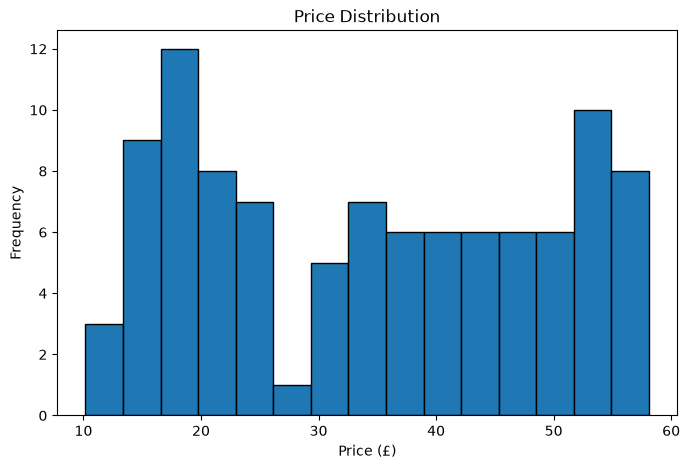

In [29]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=15, edgecolor="black")

plt.title("Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")

plt.show()

The graph shows how the book prices are spread out. Most books cost between £15–25 and £45–55, while only a few books are priced between £25–30. Overall, the books have a wide range of prices.

In [34]:
import pandas as pd

# Reload the original dataset
df = pd.read_csv("books.csv")

# Remove any extra header rows
df = df[df["Rating"] != "Rating"]

# Reset the index
df = df.reset_index(drop=True)

# Convert ratings to numbers
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

print(df["Rating"].unique())
df.head()

[2 1 3 5 4]


,Title,Category,Price,Rating,Availability,Description,UPC,Reviews,URL
0,It's Only the Himalayas,Travel,£45.17,2,In stock (19 available),"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,2,In stock (19 available),Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,1,In stock (19 available),"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,1,In stock (19 available),"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,3,In stock (19 available),This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


RATING DISTRIBUTION

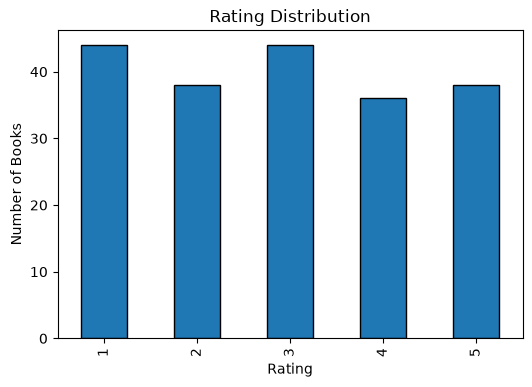

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["Rating"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()


The graph shows the number of books in each rating category. Ratings 1 and 3 have the highest number of books, while rating 4 has the fewest. Overall, the ratings are fairly evenly distributed.


Average Price by Category

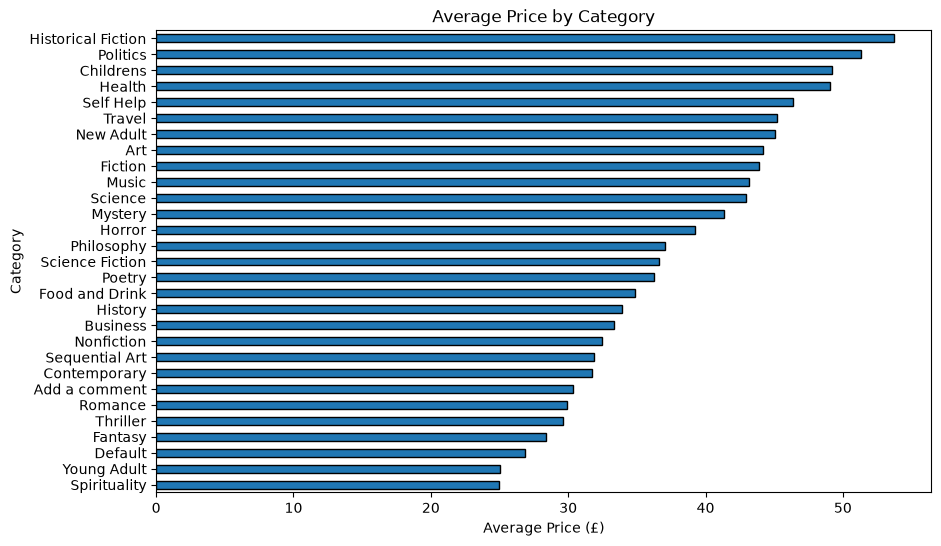

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove duplicate header row if present
df = df[df["Price"] != "Price"]

# Convert Price to numeric
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("£", "", regex=False)
)

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Remove rows with missing Price or Category
df = df.dropna(subset=["Price", "Category"])

# Calculate average price
avg_price = df.groupby("Category")["Price"].mean().sort_values()

# Plot
plt.figure(figsize=(10,6))
avg_price.plot(kind="barh", edgecolor="black")

plt.title("Average Price by Category")
plt.xlabel("Average Price (£)")
plt.ylabel("Category")

plt.show()

The chart shows the average price of books in each category. Historical Fiction has the highest average price, while Spirituality and Young Adult have the lowest. Overall, the average prices are different across categories.

Price vs Rating

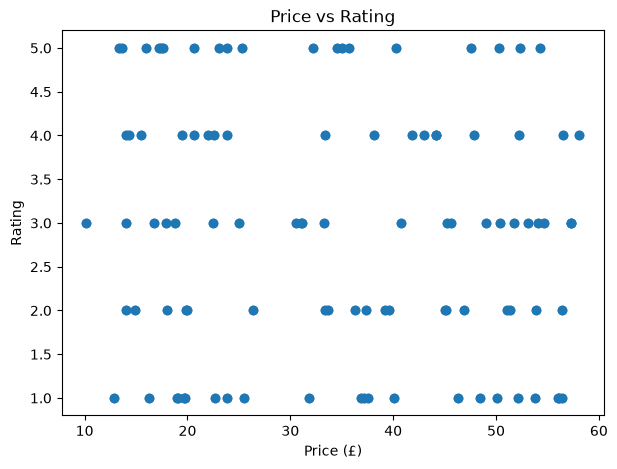

In [39]:
plt.figure(figsize=(7,5))

plt.scatter(df["Price"], df["Rating"])

plt.title("Price vs Rating")
plt.xlabel("Price (£)")
plt.ylabel("Rating")

plt.show()

The graph shows the relationship between book prices and ratings. The points are spread across all ratings, so there is no clear connection between price and rating.

Word Cloud

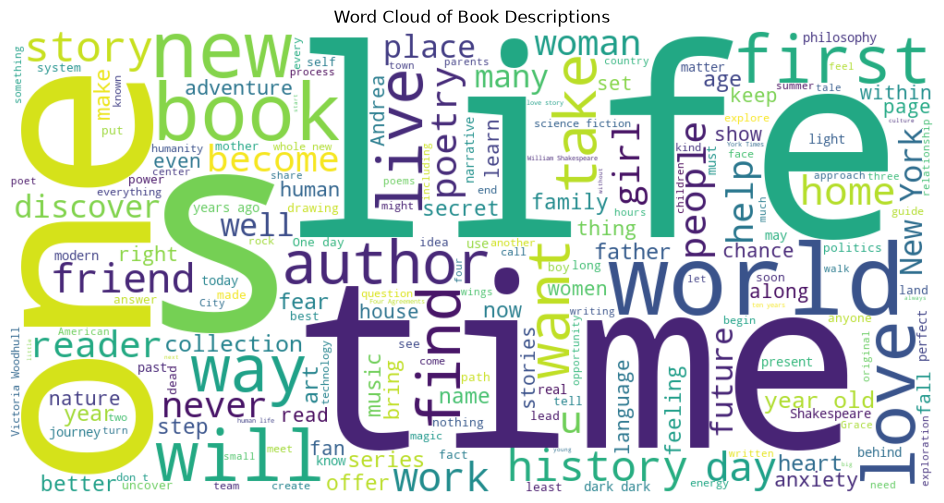

In [40]:
text = " ".join(df["Description"].fillna("").astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title("Word Cloud of Book Descriptions")

plt.show()


The word cloud shows the most common words used in book descriptions. Bigger words like "time", "life", "book", and "world" appear more often than the smaller words.

Summary Statistics

In [43]:
print("Summary Statistics")
display(df.describe())

print("\nBooks per Category")
display(df["Category"].value_counts())

print("\nAverage Price by Category")
display(df.groupby("Category")["Price"].mean().sort_values())

print("\nRating Distribution")
display(df["Rating"].value_counts().sort_index())

Summary Statistics


,Price,Rating
count,200.000000,200.000000
mean,34.560700,2.930000
std,14.601704,1.419569
min,10.160000,1.000000
25%,19.897500,2.000000
50%,34.775000,3.000000
75%,47.967500,4.000000
max,58.110000,5.000000



Books per Category


Category
Sequential Art        28
Nonfiction            24
Default               18
Poetry                14
Food and Drink        10
Add a comment         10
Fiction               10
Young Adult            8
History                8
Fantasy                8
Music                  6
Thriller               6
Mystery                6
Childrens              6
Science Fiction        4
Philosophy             4
Spirituality           4
Romance                4
Travel                 2
Politics               2
Business               2
Art                    2
Contemporary           2
New Adult              2
Horror                 2
Health                 2
Self Help              2
Science                2
Historical Fiction     2
Name: count, dtype: int64


Average Price by Category


Category
Spirituality          24.950000
Young Adult           25.047500
Default               26.847778
Fantasy               28.385000
Thriller              29.626667
Romance               29.900000
Add a comment         30.342000
Contemporary          31.770000
Sequential Art        31.906429
Nonfiction            32.482500
Business              33.340000
History               33.940000
Food and Drink        34.886000
Poetry                36.238571
Science Fiction       36.630000
Philosophy            37.025000
Horror                39.250000
Mystery               41.316667
Science               42.960000
Music                 43.196667
Fiction               43.872000
Art                   44.180000
New Adult             45.070000
Travel                45.170000
Self Help             46.350000
Health                49.050000
Childrens             49.220000
Politics              51.330000
Historical Fiction    53.740000
Name: Price, dtype: float64


Rating Distribution


Rating
1    44
2    38
3    44
4    36
5    38
Name: count, dtype: int64

# Task 4 - Insights and Interpretation

## Observations

1. A total of 100 books were successfully scraped from the Books to Scrape website.

2. Missing descriptions were handled during preprocessing, and duplicate books were removed using the UPC field.

3. Most books have ratings between 3 and 5, indicating that higher-rated books are more common in the dataset.

4. Book prices vary across different categories, with some categories having noticeably higher average prices.

5. The Price vs Rating scatter plot shows no strong relationship between a book's price and its rating.

6. The word cloud highlights the most common words used in book descriptions.

7. Feature engineering, such as price_band and affordability_score, helps compare books based on price and ratings.


## Conclusion

This project successfully demonstrates web scraping using Scrapy, data preprocessing with Pandas, feature engineering, visualization, and exploratory data analysis. The generated visualizations help understand pricing, ratings, and category-wise patterns in the dataset.

## Limitations

- Data was collected from only one website.
- Only 100 books were analyzed.
- Customer review text was unavailable, so book descriptions were used for text analysis.
- Ratings are limited to five categorical levels.